In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import mlacca_functions as mlcf
from sklearn.utils.class_weight import compute_class_weight

In [2]:
data_folder = 'data\\csv_files\\molec_db'

save_csvs_folder = 'data\\csv_files'
save_plots_folder = 'data\\plots\\van_krevelens'

In [3]:
LM_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and 'l&m' in x]

In [4]:
# Functions
def get_elements_from_formula(formula) -> dict:
    elements = {}
    current_element = ''
    current_count = ''
    for char in formula:
        if char.isupper():
            if current_element:
                elements[current_element] = int(current_count) if current_count else 1
            current_element = char
            current_count = ''
        elif char.islower():
            current_element += char
        elif char.isdigit():
            current_count += char
    if current_element:
        elements[current_element] = int(current_count) if current_count else 1
    return elements


def get_peptide_formula(sequence, amino_acids_dict) -> dict:
    total_elements = {}
    for aa in sequence:
        aa_elements = amino_acids_dict.get(aa, {})
        for element, count in aa_elements.items():
            total_elements[element] = total_elements.get(element, 0) + count
    return total_elements

def annotate_aa_plot(text,df,ax,xytext):
    ax.annotate(text,fontsize=14,
                xy=(df.loc[text]['O/C'],df.loc[text]['H/C']),
                xytext=xytext,arrowprops=dict(arrowstyle="-"),
                horizontalalignment='center', verticalalignment='bottom')


In [5]:
overall_df = pd.DataFrame()
amino_acids_dict = {}

for file in LM_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)

    # Further processing and analysis of df

    category = file.replace('.csv', '').replace('l&m-', '')

    # save the results with the category name

    if category == 'amino_acid':
        for letter in df['1-letter code']:
            amino_acids_dict[letter] = get_elements_from_formula(df['FORMULA'][df['1-letter code'] == letter].to_list()[0])
        
        category = 'peptide'
    
    df_slice = pd.DataFrame({'category':[category] * len(df)})
    atomic_dict = {'C':[], 'H':[], 'O':[], 'N':[], 'S':[], 'P':[]}

    try:
        df_slice['formula'] = df['FORMULA']

    except KeyError:
        if category == 'peptide':
            seqs = df['Sequence'].to_list()
            formula_dict_list = [get_peptide_formula(seq, amino_acids_dict) for seq in seqs]
            df_slice['formula'] = [''.join([f'{x}{formula_dict[x]}' for x in formula_dict]) for formula_dict in formula_dict_list]

        elif category == 'lignin':
            for element in atomic_dict.keys():
                if element in df.columns:
                    atomic_dict[element] = df[element].to_list()
                else:
                    atomic_dict[element] = [0] * len(df)
    
    if category != 'lignin':
        for formula in df_slice['formula']:
            elements = get_elements_from_formula(formula)
            for element in atomic_dict.keys():
                atomic_dict[element].append(elements.get(element, 0))
    
    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)
    
    if len(overall_df) == 0:
        overall_df = df_slice
    else:
        overall_df = pd.concat([overall_df, df_slice], ignore_index=True)

# calculate elemental ratios
for element in atomic_dict.keys():
    if element != 'C':
        overall_df[f'{element}/C'] = overall_df[element] / overall_df['C']

In [6]:
# print the count for each category
print(overall_df['category'].value_counts())

# sort the dataframe by category
overall_df = overall_df.sort_values(by=['category']).reset_index(drop=True)

category
lipid           5109
lignin           297
peptide          263
tannin           192
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


In [7]:
# since the dataset is not balanced as there are more samples in some categories, we can compute class weights

class_weights = compute_class_weight('balanced', classes=np.unique(overall_df['category']), y=overall_df['category'])
weights_dict = {cls: weight for cls, weight in zip(np.unique(overall_df['category']), class_weights)}

overall_df['weights'] = [weights_dict[cat] for cat in overall_df['category']]

In [8]:
overall_df.to_csv(f'{save_csvs_folder}\\new_vk_areas_df.csv', index=False)

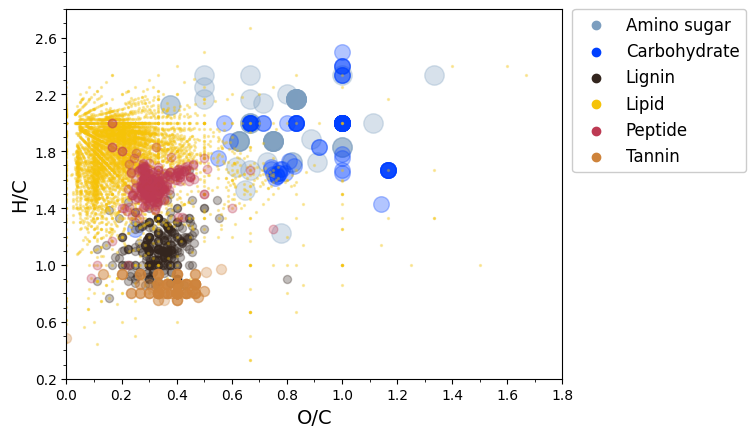

In [9]:
#plot the Van Krevelen diagram
fig, ax = plt.subplots()

for category in overall_df['category'].unique():
    subset = overall_df[overall_df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'],
               c = mlcf.vk_region_colours[category],
               alpha=0.3, s=1e4/len(overall_df[overall_df['category'] == category])) # the size of the points is inversely proportional to the number of points in that category

for cat in overall_df['category'].unique():
    ax.scatter(None,None,c=mlcf.vk_region_colours[cat],
               label=cat.replace('_',' ').capitalize() if cat != 'pah' else 'PAH')

ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)

mlcf.set_axis_ticks(overall_df['O/C'].values,ax,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
mlcf.set_axis_ticks(overall_df['H/C'].values,ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.savefig(f'{save_plots_folder}\\vk_diagram.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')


In [10]:
code_cipher = {
    'A':'Ala',
    'R':'Arg',
    'N':'Asn',
    'D':'Asp',
    'C':'Cys',
    'Q':'Gln',
    'E':'Glu',
    'G':'Gly',
    'H':'His',
    'I':'Ile',
    'L':'Leu',
    'K':'Lys',
    'M':'Met',
    'F':'Phe',
    'P':'Pro',
    'S':'Ser',
    'T':'Thr',
    'W':'Trp',
    'Y':'Tyr',
    'V':'Val',
}
amino_acids_dict_3lett = {code_cipher[aa]:amino_acids_dict[aa] for aa in amino_acids_dict}
aa_df = pd.DataFrame(amino_acids_dict_3lett).T
dims = ['O/C','H/C','N/C']
for d in dims:
    aa_df[d] = aa_df[d[0]] / aa_df['C']
aa_df

,C,H,O,N,S,O/C,H/C,N/C
Ala,3.0,5.0,1.0,1.0,NaN,0.333333,1.666667,0.333333
Arg,6.0,12.0,1.0,4.0,NaN,0.166667,2.000000,0.666667
Asn,4.0,6.0,2.0,2.0,NaN,0.500000,1.500000,0.500000
Asp,4.0,5.0,3.0,1.0,NaN,0.750000,1.250000,0.250000
Cys,3.0,5.0,1.0,1.0,1.0,0.333333,1.666667,0.333333
Glu,5.0,7.0,3.0,1.0,NaN,0.600000,1.400000,0.200000
Gln,5.0,8.0,2.0,2.0,NaN,0.400000,1.600000,0.400000
Gly,2.0,3.0,1.0,1.0,NaN,0.500000,1.500000,0.500000
His,6.0,7.0,1.0,3.0,NaN,0.166667,1.166667,0.500000
Ile,6.0,11.0,1.0,1.0,NaN,0.166667,1.833333,0.166667


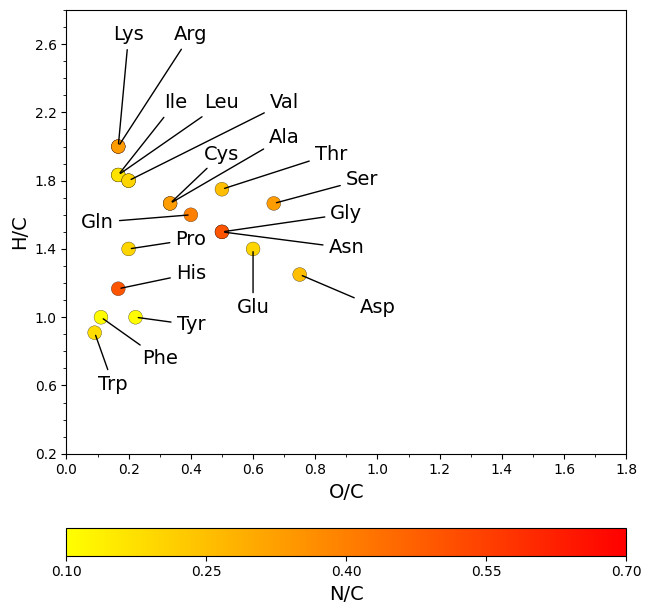

In [29]:
fig, ax = plt.subplots(figsize=(6.4,6),layout='constrained')

norm_lims = (np.round(aa_df['N/C'].min(),1), np.round(aa_df['N/C'].max(),1))

norm = mpl.colors.Normalize(vmin=norm_lims[0], vmax=norm_lims[1])

ax_plot = ax.scatter(aa_df['O/C'],aa_df['H/C'],s=100,
                     norm=norm,c=aa_df['N/C'],cmap='autumn_r',edgecolors='k',lw=.2)

for combo in [['Lys',(.2,2.6)],
              ['Arg',(.4,2.6)],
              ['Ile',(.35,2.2)],
              ['Leu',(.5,2.2)],
              ['Val',(.7,2.2)],
              ['Cys',(.5,1.9)],
              ['Ala',(.7,2.0)],
              ['Thr',(.85,1.9)],
              ['Ser',(.95,1.75)],
              ['Gln',(.1,1.5)],
              ['Gly',(.9,1.55)],
              ['Asn',(.9,1.35)],
              ['Glu',(.6,1)],
              ['Asp',(1,1)],
              ['Pro',(.4,1.4)],
              ['His',(.4,1.2)],
              ['Tyr',(.4,.9)],
              ['Phe',(.3,.7)],
              ['Trp',(.15,.55)],
              ]:
    annotate_aa_plot(combo[0],aa_df,ax,(combo[1]))

mlcf.set_axis_ticks(overall_df['O/C'].values,ax,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
mlcf.set_axis_ticks(overall_df['H/C'].values,ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)
ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)
cbar = fig.colorbar(ax_plot,ticks=np.linspace(norm_lims[0],norm_lims[1],5),location='bottom')
cbar.set_label(label='N/C',size=14)
fig.savefig(f'{save_plots_folder}\\amino_acids.svg',dpi=600, facecolor = '#fff', bbox_inches='tight')

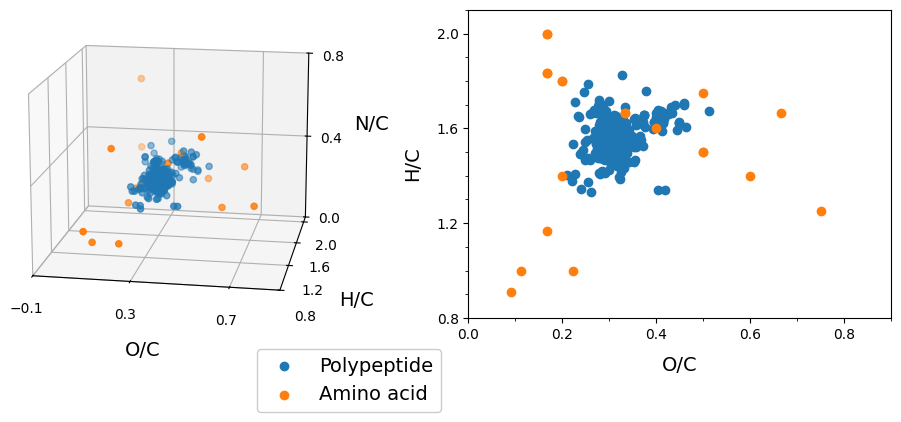

In [32]:
pept_df = pd.DataFrame(formula_dict_list)
for d in dims:
    pept_df[d] = pept_df[d[0]] / pept_df['C']

fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(121,projection='3d')

aa_df['type'] = ['Amino acid']*len(aa_df)
pept_df['type'] = ['Polypeptide']*len(pept_df)

concat_df = pd.concat((aa_df,pept_df))

label_dict = {'Polypeptide':'tab:blue','Amino acid':'tab:orange'}

ax.scatter(concat_df['O/C'],concat_df['H/C'],concat_df['N/C'],
           c=[label_dict[x] for x in concat_df['type']],)

mlcf.set_axis_ticks(concat_df['O/C'],ax,axis='x',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1)
mlcf.set_axis_ticks(concat_df['H/C'],ax,axis='y',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1)
mlcf.set_axis_ticks(concat_df['N/C'],ax,axis='z',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1)

ax.set_xlabel('O/C', fontsize=14, labelpad = 8)
ax.set_ylabel('H/C', fontsize=14, labelpad = 10)
ax.set_zlabel('N/C', fontsize=14, labelpad = 10)

ax.view_init(elev=15,azim=-80)
ax.set_box_aspect(None, zoom=1.2)


ax2 = fig.add_subplot(122)

for t in ['Polypeptide','Amino acid']:
    ax2.scatter(concat_df[concat_df['type']==t]['O/C'],concat_df[concat_df['type']==t]['H/C'],
                label=t,c=label_dict[t])

mlcf.set_axis_ticks(concat_df['O/C'].values,ax2,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
mlcf.set_axis_ticks(concat_df['H/C'].values,ax2,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

ax2.set_xlabel('O/C', fontsize=14, labelpad = 10)
ax2.set_ylabel('H/C', fontsize=14, labelpad = 10)

ax2.legend(framealpha=1,bbox_to_anchor=(-.5,-.1), loc='upper left', borderaxespad=0,fontsize=14)

fig.savefig(f'{save_plots_folder}\\amino_acids_&_peptides.svg',dpi=600, facecolor = '#fff', bbox_inches='tight')

# Create a CSV file to include PAHs as well 

In [13]:
all_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and x not in LM_files]

In [14]:
overall_df_with_pahs = pd.DataFrame()

for file in all_files:
    df = pd.read_csv(os.path.join(data_folder, file))

    category = file.replace('.csv', '')

    atomic_dict = {'C':[], 'H':[], 'O':[], 'N':[], 'S':[], 'P':[]}

    df_slice = pd.DataFrame({'category':[category] * len(df)})
    df_slice['formula'] = df['FORMULA']

    for formula in df_slice['formula']:
        elements = get_elements_from_formula(formula)

        for element in atomic_dict.keys():
            atomic_dict[element].append(elements.get(element, 0))

    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)

    for element in atomic_dict.keys():
        if element != 'C':
            df_slice[f'{element}/C'] = df_slice[element] / df_slice['C']
    
    overall_df_with_pahs = pd.concat([overall_df, df_slice], ignore_index=True) if len(overall_df_with_pahs) == 0 else pd.concat([overall_df_with_pahs, df_slice], ignore_index=True)

# print the count for each category
print(overall_df_with_pahs['category'].value_counts())

# sort the dataframe by category
overall_df_with_pahs = overall_df_with_pahs.sort_values(by=['category']).reset_index(drop=True)

category
lipid           5109
lignin           297
peptide          263
tannin           192
pah               86
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


In [15]:
# since the dataset is not balanced as there are more samples in some categories, we can compute class weights

class_weights = compute_class_weight('balanced', classes=np.unique(overall_df_with_pahs['category']), y=overall_df_with_pahs['category'])
weights_dict_with_pahs = {cls: weight for cls, weight in zip(np.unique(overall_df_with_pahs['category']), class_weights)}

overall_df_with_pahs['weights'] = [weights_dict_with_pahs[cat] for cat in overall_df_with_pahs['category']]

overall_df_with_pahs.to_csv(f'{save_csvs_folder}\\new_vk_areas_with_pahs.csv', index=False)

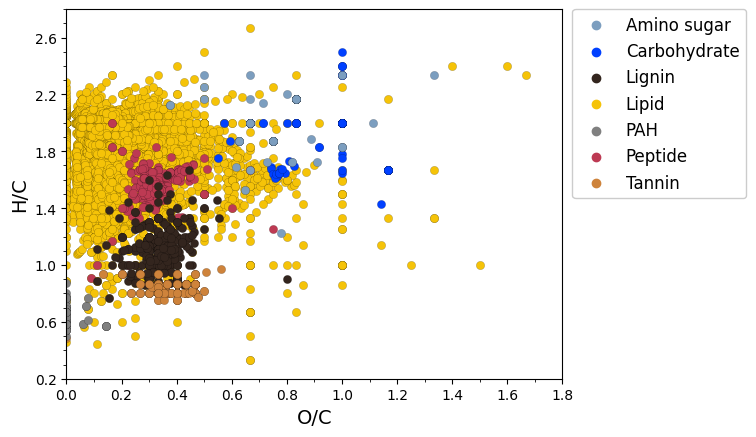

In [16]:
#plot the Van Krevelen diagram
fig, ax_2d = plt.subplots()

for category in ['lipid','peptide','carbohydrate','amino_sugar','lignin','tannin','pah']:
    subset = overall_df_with_pahs[overall_df_with_pahs['category'] == category]
    ax_2d.scatter(subset['O/C'], subset['H/C'],
                  c=mlcf.vk_region_colours[category],
                  edgecolor='k',lw=.1)
    
for cat in overall_df_with_pahs['category'].unique():
    ax_2d.scatter(None,None,c=mlcf.vk_region_colours[cat],
               label=cat.replace('_',' ').capitalize() if cat != 'pah' else 'PAH')

ax_2d.set_xlabel('O/C', fontsize=14)
ax_2d.set_ylabel('H/C', fontsize=14)

mlcf.set_axis_ticks(overall_df_with_pahs['O/C'].values,ax_2d,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'].values,ax_2d,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

ax_2d.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
fig.savefig(f'{save_plots_folder}\\vk_diagram_with_pahs.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')

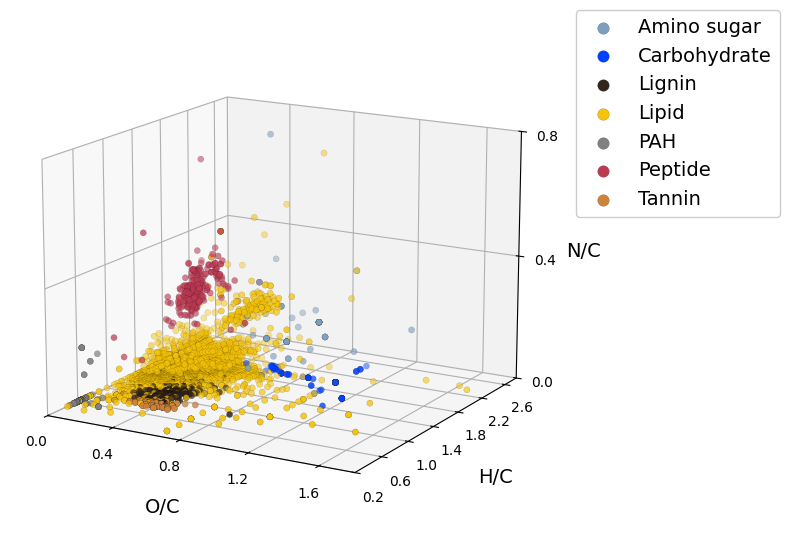

In [17]:
fig = plt.figure(figsize=(12,7)) # width, height

ax_3d = fig.add_subplot(111, projection='3d')

ax_3d.scatter(overall_df_with_pahs['O/C'], overall_df_with_pahs['H/C'], overall_df_with_pahs['N/C'],
              c=[mlcf.vk_region_colours[cat] for cat in overall_df_with_pahs['category']],
              edgecolor='k',lw=.1)

mlcf.set_axis_ticks(overall_df_with_pahs['O/C'],ax_3d,axis='x',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(0,1.8),upper_lim=max(0,1.8))
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'],ax_3d,axis='y',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(.2,2.8),upper_lim=max(.2,2.8))
mlcf.set_axis_ticks(overall_df_with_pahs['N/C'],ax_3d,axis='z',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(0,.8),upper_lim=max(0,.8))

for cat in overall_df_with_pahs['category'].unique():
    ax_3d.scatter(10,10,10,c=mlcf.vk_region_colours[cat],alpha=1,edgecolor='k',lw=.1,
                  label=cat.replace('_',' ').capitalize() if cat != 'pah' else 'PAH',
                  s=70)
    
ax_3d.legend(framealpha=1,bbox_to_anchor=(1.05,1), loc='upper left', borderaxespad=0, fontsize=14)
ax_3d.view_init(elev=15, azim=-60)

ax_3d.set_xlabel('O/C',fontsize=14,labelpad=15)
ax_3d.set_ylabel('H/C',fontsize=14,labelpad=15)
ax_3d.set_zlabel('N/C',fontsize=14,labelpad=8)
fig.savefig(f'{save_plots_folder}\\vk_diagram_with_pahs_3d.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')

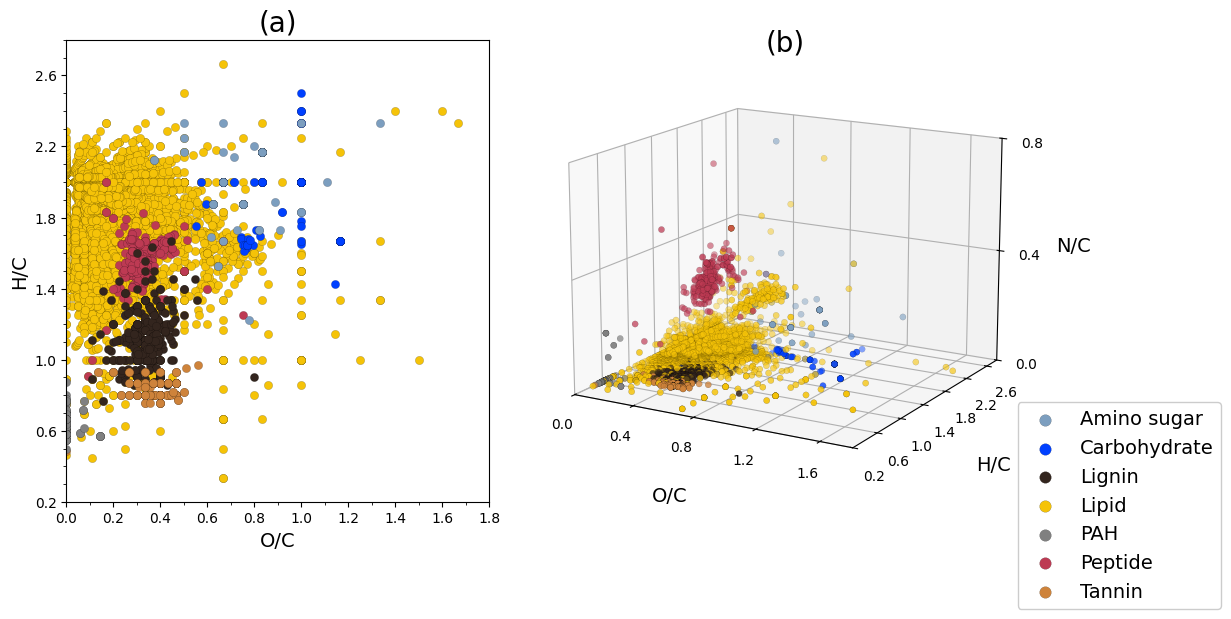

In [18]:
fig = plt.figure(figsize=(12,6))

# 2D -----------------------------------------------------------------------------------------------------
ax_2d = fig.add_subplot(121)

for category in ['lipid','peptide','carbohydrate','amino_sugar','lignin','tannin','pah']:
    subset = overall_df_with_pahs[overall_df_with_pahs['category'] == category]
    ax_2d.scatter(subset['O/C'], subset['H/C'],
                  c=mlcf.vk_region_colours[category],
                  edgecolor='k',lw=.1)

ax_2d.set_xlabel('O/C', fontsize=14)
ax_2d.set_ylabel('H/C', fontsize=14)

mlcf.set_axis_ticks(overall_df_with_pahs['O/C'].values,ax_2d,axis='x',major_ticks_interval=.2,minor_ticks_interval=.1,rounding=1,lower_lim=0)
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'].values,ax_2d,axis='y',major_ticks_interval=.4,minor_ticks_interval=.1,rounding=1)

# 3D -----------------------------------------------------------------------------------------------------
ax_3d = fig.add_subplot(122, projection='3d')

ax_3d.scatter(overall_df_with_pahs['O/C'], overall_df_with_pahs['H/C'], overall_df_with_pahs['N/C'],
           c=[mlcf.vk_region_colours[cat] for cat in overall_df_with_pahs['category']],
           edgecolor='k',lw=.1)

mlcf.set_axis_ticks(overall_df_with_pahs['O/C'],ax_3d,axis='x',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(0,1.8),upper_lim=max(0,1.8))
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'],ax_3d,axis='y',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(.2,2.8),upper_lim=max(.2,2.8))
mlcf.set_axis_ticks(overall_df_with_pahs['N/C'],ax_3d,axis='z',major_ticks_interval=.4,minor_ticks_interval=None,rounding=1,lower_lim=min(0,.8),upper_lim=max(0,.8))

for cat in overall_df_with_pahs['category'].unique():
    ax_3d.scatter(10,10,10,c=mlcf.vk_region_colours[cat],alpha=1,edgecolor='k',lw=.1,
                  label=cat.replace('_',' ').capitalize() if cat != 'pah' else 'PAH',
                  s=70)
    
ax_3d.legend(framealpha=1,bbox_to_anchor=(1.05,-0.3), loc='lower left', borderaxespad=0, fontsize=14)
ax_3d.view_init(elev=15, azim=-60)

ax_3d.set_xlabel('O/C',fontsize=14,labelpad=15)
ax_3d.set_ylabel('H/C',fontsize=14,labelpad=15)
ax_3d.set_zlabel('N/C',fontsize=14,labelpad=8)

ax_3d.set_box_aspect(None, zoom=1.15)

ax_2d.set_title('(a)',fontsize=20)
ax_3d.set_title('(b)',fontsize=20)
fig.savefig(f'{save_plots_folder}\\vk_diagram_with_pahs_2d_&_3d.svg', dpi = 600, facecolor = '#fff', bbox_inches='tight')